In [2]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

GPU available: False


In [3]:
%pip install -q torch torchvision timm matplotlib scikit-learn tqdm datasets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Quick check: can pandas import correctly?
import sys

try:
    import pandas as pd
    print("pandas OK:", pd.__version__)
    print("pandas path:", pd.__file__)
except Exception as e:
    print("pandas import FAILED")
    print(type(e).__name__ + ":", e)
    # Helpful: show if a local file is shadowing pandas
    print("sys.path[0] (cwd entry):", sys.path[0])


pandas OK: 3.0.2
pandas path: c:\Users\fadhe\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\__init__.py


In [11]:
# Fix pandas (required for Hugging Face `datasets`)
%pip install -q --upgrade --force-reinstall pandas

Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires pandas<3,>=1.4.0, but you have pandas 3.0.2 which is incompatible.

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Optional in Colab: uncomment if image loading/decode issues appear.
# %pip install -q pillow-simd

In [5]:
from datasets import load_dataset

dataset = load_dataset("tanganke/stanford_cars")

c:\Users\fadhe\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyboardInterrupt: 

In [5]:
print(dataset)

id_to_label = dataset['train'].features['label'].names
idx_to_class = {i: name for i, name in enumerate(id_to_label)}

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 8144
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 8041
    })
    contrast: Dataset({
        features: ['image', 'label'],
        num_rows: 8041
    })
    gaussian_noise: Dataset({
        features: ['image', 'label'],
        num_rows: 8041
    })
    impulse_noise: Dataset({
        features: ['image', 'label'],
        num_rows: 8041
    })
    jpeg_compression: Dataset({
        features: ['image', 'label'],
        num_rows: 8041
    })
    motion_blur: Dataset({
        features: ['image', 'label'],
        num_rows: 8041
    })
    pixelate: Dataset({
        features: ['image', 'label'],
        num_rows: 8041
    })
    spatter: Dataset({
        features: ['image', 'label'],
        num_rows: 8041
    })
})


(np.float64(-0.5), np.float64(699.5), np.float64(524.5), np.float64(-0.5))

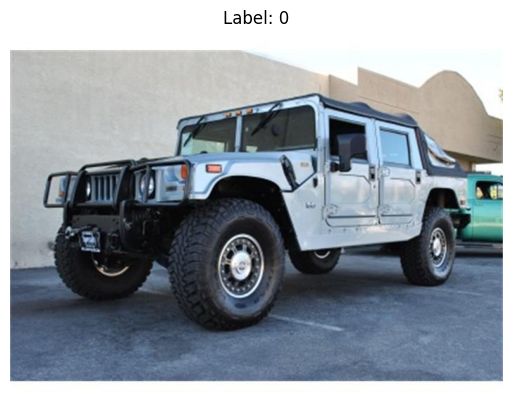

In [6]:
import matplotlib.pyplot as plt

sample = dataset['train'][0]
image = sample['image']
label = sample['label']

plt.imshow(image)
plt.title(f"Label: {label}")
plt.axis('off')

next step preprocessing

In [7]:
from torchvision import transforms

In [9]:
from torchvision import transforms
from torchvision.transforms import InterpolationMode

IMG_SIZE = 300

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0), interpolation=InterpolationMode.BICUBIC),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.AutoAugment(policy=transforms.AutoAugmentPolicy.IMAGENET),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.12), ratio=(0.3, 3.3), value='random'),
])

eval_transform = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.12), interpolation=InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [11]:
from PIL import Image

def transform_example(example, image_transform):
    image = example['image']

    # Case 1: list of images
    if isinstance(image, list):
        processed = []
        for img in image:
            if not isinstance(img, Image.Image):
                img = Image.fromarray(img)
            if img.mode != "RGB":
                img = img.convert("RGB")
            processed.append(image_transform(img))

        example['pixel_values'] = torch.stack(processed)

    else:
        # Single image
        if not isinstance(image, Image.Image):
            image = Image.fromarray(image)
        if image.mode != "RGB":
            image = image.convert("RGB")

        example['pixel_values'] = image_transform(image)

    return example

In [10]:
splits = dataset['train'].train_test_split(
    test_size=0.1,
    seed=42,
    stratify_by_column='label'
 )

train_dataset = splits['train'].with_transform(
    lambda example: transform_example(example, train_transform)
 )
val_dataset = splits['test'].with_transform(
    lambda example: transform_example(example, eval_transform)
 )
test_dataset = dataset['test'].with_transform(
    lambda example: transform_example(example, eval_transform)
 )

In [11]:
sample = train_dataset[0]

print(type(sample['pixel_values']))
print(sample['pixel_values'].shape)

<class 'torch.Tensor'>
torch.Size([3, 300, 300])


After preprocessing:
Type: torch.Tensor
Size: 3 × 224 × 224
Values: normalized (small numbers around -1 → 1)
Format: ready for deep learning

Model (Pretrained EfficientNetV2)

In [12]:
import torch
import torch.nn as nn
import timm

In [13]:
import timm

model = timm.create_model(
    "efficientnetv2_rw_m",
    pretrained=True,
    num_classes=196,
)

print("Using model: efficientnetv2_rw_m")

model.safetensors:   0%|          | 0.00/214M [00:00<?, ?B/s]

Using model: efficientnetv2_rw_m


In [14]:
for param in model.parameters():
    param.requires_grad = False

# Fine-tune classifier + final blocks for stronger transfer on cars dataset.
for name, param in model.named_parameters():
    if any(k in name for k in ["blocks.5", "blocks.6", "conv_head", "bn2", "classifier"]):
        param.requires_grad = True

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable_params:,} / {total_params:,}")

Trainable params: 39,670,546 / 51,505,430


In [15]:
# model.fc already set to 196 classes above

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

training

In [17]:
from torch.utils.data import DataLoader
import torch.optim as optim

In [18]:
# DataLoaders are created after defining collate_fn

In [19]:
import torch

def collate_fn(batch):
    pixel_values = torch.stack([item['pixel_values'] for item in batch])
    labels = torch.tensor([item['label'] for item in batch])

    return {
        'pixel_values': pixel_values,
        'label': labels
    }

In [20]:
from torch.utils.data import DataLoader
import os

num_workers = 2 if os.name == "nt" else 4
pin_memory = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=32 if torch.cuda.is_available() else 16,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=num_workers > 0,
    drop_last=True,
    prefetch_factor=2 if num_workers > 0 else None,
    )

val_loader = DataLoader(
    val_dataset,
    batch_size=64 if torch.cuda.is_available() else 16,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=num_workers > 0,
    prefetch_factor=2 if num_workers > 0 else None,
    )

test_loader = DataLoader(
    test_dataset,
    batch_size=64 if torch.cuda.is_available() else 16,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=num_workers > 0,
    prefetch_factor=2 if num_workers > 0 else None,
    )

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [21]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

head_params = []
backbone_params = []
for name, p in model.named_parameters():
    if not p.requires_grad:
        continue
    if "classifier" in name:
        head_params.append(p)
    else:
        backbone_params.append(p)

optimizer = optim.AdamW(
    [
        {"params": backbone_params, "lr": 8e-5},
        {"params": head_params, "lr": 2.5e-4},
    ],
    weight_decay=1e-4,
    betas=(0.9, 0.999),
)

In [22]:
import os
import torch
from tqdm.auto import tqdm

num_epochs = 24 if torch.cuda.is_available() else 4
patience = 5
best_val_top1 = 0.0
epochs_no_improve = 0

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)
use_amp = torch.cuda.is_available()
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

# Optional resume for continued fine-tuning in Colab.
if os.path.exists("best_model.pth"):
    try:
        state_dict = torch.load("best_model.pth", map_location=device)
        model.load_state_dict(state_dict)
        print("Resumed from existing best_model.pth")
    except RuntimeError as e:
        print("Checkpoint exists but does not match current model architecture.")
        print("Starting fresh from pretrained weights.")
        print(f"Details: {e}")
else:
    print("No prior checkpoint found, starting fresh from pretrained weights")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs} [train]", leave=False)
    for batch in pbar:
        images = batch['pixel_values'].to(device, non_blocking=True)
        labels = batch['label'].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    scheduler.step()

    model.eval()
    correct_top1 = 0
    correct_top3 = 0
    total = 0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch + 1}/{num_epochs} [val]", leave=False):
            images = batch['pixel_values'].to(device, non_blocking=True)
            labels = batch['label'].to(device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = model(images)

            top1_preds = outputs.argmax(dim=1)
            top3_preds = torch.topk(outputs, k=3, dim=1).indices

            total += labels.size(0)
            correct_top1 += (top1_preds == labels).sum().item()
            correct_top3 += (top3_preds == labels.unsqueeze(1)).any(dim=1).sum().item()

    val_top1 = 100.0 * correct_top1 / max(total, 1)
    val_top3 = 100.0 * correct_top3 / max(total, 1)
    train_loss = running_loss / max(len(train_loader), 1)
    current_lr = scheduler.get_last_lr()[0]

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"train_loss={train_loss:.4f} | val_top1={val_top1:.2f}% | "
        f"val_top3={val_top3:.2f}% | lr={current_lr:.2e}"
    )

    if val_top1 > best_val_top1:
        best_val_top1 = val_top1
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model.pth")
        print("Saved new best_model.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping triggered")
            break

print(f"Training complete. Best val top-1: {best_val_top1:.2f}%")

No prior checkpoint found, starting fresh from pretrained weights


/tmp/ipykernel_2607/382134396.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 1/24 [train]:   0%|          | 0/229 [00:00<?, ?it/s]

/tmp/ipykernel_2607/382134396.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 1/24 [val]:   0%|          | 0/13 [00:00<?, ?it/s]

...

Epoch 23/24 [val]:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 23/24 | train_loss=1.3564 | val_top1=77.91% | val_top3=92.15% | lr=1.34e-06


Epoch 24/24 [train]:   0%|          | 0/229 [00:00<?, ?it/s]

Epoch 24/24 [val]:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 24/24 | train_loss=1.3376 | val_top1=77.79% | val_top3=92.27% | lr=1.00e-06
Training complete. Best val top-1: 78.16%


In [23]:
# Deprecated duplicate training loop removed intentionally.
# Use the previous training cell as the single source of training.
print("Skipped: duplicate training loop. Use the main training cell above.")

Skipped: duplicate training loop. Use the main training cell above.


In [24]:
import os

if os.path.exists("best_model.pth"):
    state_dict = torch.load("best_model.pth", map_location=device)
    try:
        model.load_state_dict(state_dict)
        print("Loaded best_model.pth")
    except RuntimeError as e:
        raise RuntimeError(
            "best_model.pth exists but does not match the current model. "
            "Train with the current architecture or remove old checkpoint.\n"
            f"Details: {e}"
        )
else:
    raise FileNotFoundError("best_model.pth not found. Run the training cell first in Colab.")

model.to(device)
model.eval()

Loaded best_model.pth


EfficientNet(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): EdgeResidual(
        (conv_exp): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): Identity()
        (conv_pwl): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): Identity()
        )
        (drop_path): Identity()
      )
      (1): EdgeResidual(
        (conv_exp)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/tmp/ipykernel_2607/956722788.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Test Top-1 Accuracy: 79.33%
Test Top-3 Accuracy: 92.41%


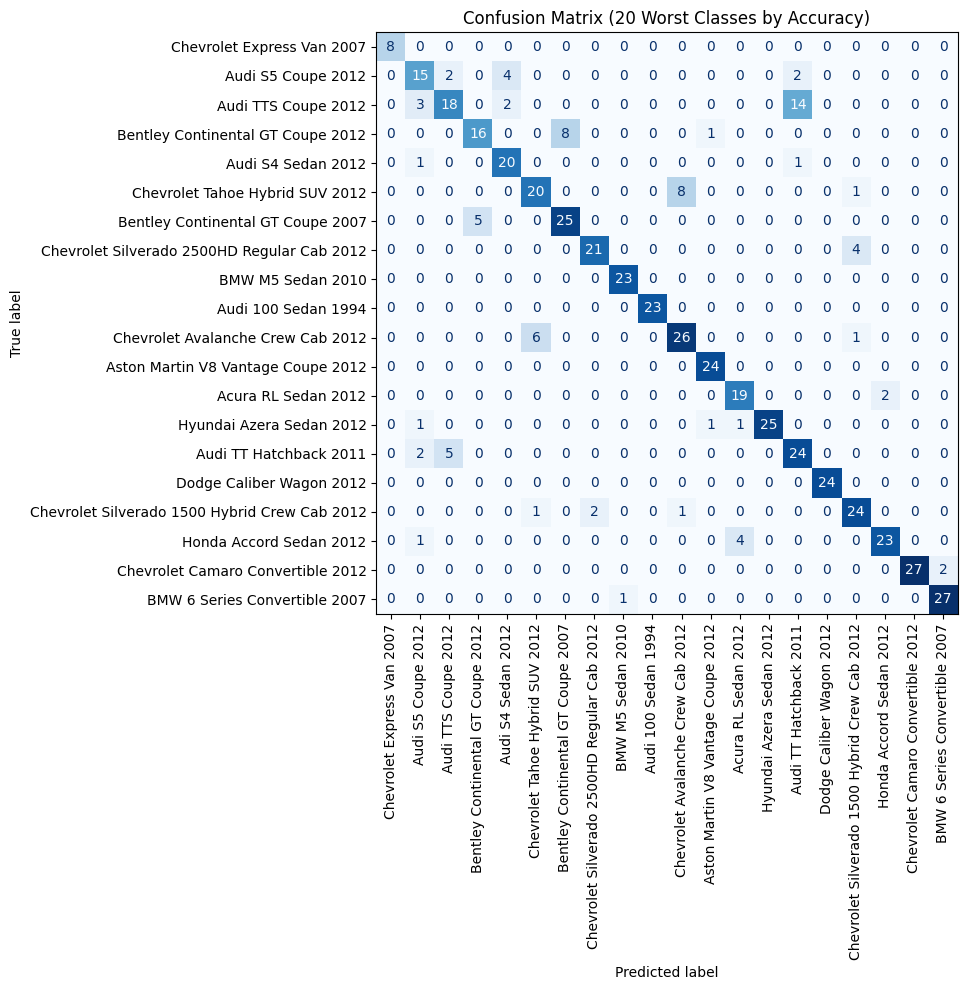

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


def evaluate_model(model, data_loader, device, num_classes, show_worst_cm=True, worst_k=20):
    model.eval()
    all_labels = []
    all_preds = []
    top3_correct = 0
    total = 0
    use_amp = torch.cuda.is_available()

    with torch.no_grad():
        for batch in data_loader:
            images = batch['pixel_values'].to(device, non_blocking=True)
            labels = batch['label'].to(device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = model(images)

            preds = torch.argmax(outputs, dim=1)
            top3 = torch.topk(outputs, k=3, dim=1).indices

            total += labels.size(0)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            top3_correct += (top3 == labels.unsqueeze(1)).any(dim=1).sum().item()

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    top1 = (all_preds == all_labels).mean() * 100
    top3 = (top3_correct / max(total, 1)) * 100

    print(f"Test Top-1 Accuracy: {top1:.2f}%")
    print(f"Test Top-3 Accuracy: {top3:.2f}%")

    cm = confusion_matrix(all_labels, all_preds, labels=np.arange(num_classes))

    if show_worst_cm:
        class_counts = np.bincount(all_labels, minlength=num_classes)
        class_acc = np.divide(
            np.diag(cm),
            class_counts,
            out=np.zeros_like(class_counts, dtype=float),
            where=class_counts > 0,
        )

        worst_class_ids = np.argsort(class_acc)[:worst_k]
        cm_worst = cm[np.ix_(worst_class_ids, worst_class_ids)]
        display_labels = [idx_to_class[i] for i in worst_class_ids]

        fig, ax = plt.subplots(figsize=(12, 10))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm_worst, display_labels=display_labels)
        disp.plot(ax=ax, cmap="Blues", xticks_rotation=90, colorbar=False)
        ax.set_title(f"Confusion Matrix ({worst_k} Worst Classes by Accuracy)")
        plt.tight_layout()
        plt.show()

    return top1, top3, cm


test_top1, test_top3, test_cm = evaluate_model(
    model=model,
    data_loader=test_loader,
    device=device,
    num_classes=196,
    show_worst_cm=True,
    worst_k=20,
)

test

In [26]:
from PIL import Image
import torchvision.transforms as transforms

infer_transform = eval_transform

# Test-time augmentation helps stabilize predictions on hard images.
tta_transform = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.12)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.88, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


def predict_topk_tta(model, image, idx_to_class, device, k=3, tta_runs=8):
    if image.mode != "RGB":
        image = image.convert("RGB")

    model.eval()
    with torch.no_grad():
        logits = model(infer_transform(image).unsqueeze(0).to(device))

        for _ in range(tta_runs):
            aug_tensor = tta_transform(image).unsqueeze(0).to(device)
            logits = logits + model(aug_tensor)

        logits = logits / (tta_runs + 1)
        probs = torch.softmax(logits, dim=1)
        top_prob, top_cls = torch.topk(probs, k)

    results = []
    for i in range(k):
        cls_id = top_cls[0][i].item()
        prob = top_prob[0][i].item()
        results.append((cls_id, idx_to_class[cls_id], prob))

    return results

In [27]:
sample = test_dataset[0]

image = sample['image']
label = sample['label']

In [28]:
if image.mode != "RGB":
    image = image.convert("RGB")

input_tensor = infer_transform(image).unsqueeze(0).to(device)

In [29]:
results = predict_topk_tta(model, image, idx_to_class, device, k=3, tta_runs=6)

print("True label:", idx_to_class[label])
print("Top 3 predictions (TTA):")
for rank, (_, class_name, prob) in enumerate(results, start=1):
    print(f"{rank}. {class_name} | Confidence: {prob:.4f}")

True label: AM General Hummer SUV 2000
Top 3 predictions (TTA):
1. AM General Hummer SUV 2000 | Confidence: 0.7189
2. Geo Metro Convertible 1993 | Confidence: 0.0786
3. Jeep Wrangler SUV 2012 | Confidence: 0.0159


In [30]:
# Kept for consistency with the previous section.
# This now mirrors the same TTA-based output used above.
results = predict_topk_tta(model, image, idx_to_class, device, k=3, tta_runs=6)

print("Top 3 predictions (TTA):")
for rank, (_, class_name, prob) in enumerate(results, start=1):
    print(f"{rank}. {class_name} | Confidence: {prob:.4f}")

Top 3 predictions (TTA):
1. AM General Hummer SUV 2000 | Confidence: 0.7351
2. Geo Metro Convertible 1993 | Confidence: 0.0773
3. Jeep Wrangler SUV 2012 | Confidence: 0.0155


In [35]:
import requests
from PIL import Image
from io import BytesIO

url = "https://images.hgmsites.net/lrg/2012-acura-tsx-4-door-sedan-i4-auto-angular-front-exterior-view_100368289_l.jpg"

response = requests.get(url)
image = Image.open(BytesIO(response.content)).convert("RGB")

In [36]:
image_tensor = infer_transform(image).unsqueeze(0).to(device)

In [37]:
model.eval()
results = predict_topk_tta(model, image, idx_to_class, device, k=3, tta_runs=8)

print("Top 3 predictions (TTA):")
for rank, (_, class_name, prob) in enumerate(results, start=1):
    print(f"{rank}. {class_name} | Confidence: {prob:.4f}")

Top 3 predictions (TTA):
1. Acura TSX Sedan 2012 | Confidence: 0.7420
2. Toyota Camry Sedan 2012 | Confidence: 0.1108
3. Acura TL Sedan 2012 | Confidence: 0.0485


In [4]:
from pathlib import Path
print(list(Path(".").glob("*.pth")))

[]


In [7]:
from __future__ import annotations

from pathlib import Path
import os
import torch

# --- Smoke test: find checkpoint near the notebook and run 1 forward pass ---
notebook_path = Path(r"c:\Users\fadhe\Downloads\DL_project2 (1).ipynb")
notebook_dir = notebook_path.parent

print("Notebook path:", notebook_path)
print("Notebook dir:", notebook_dir)
print("Current working dir:", Path.cwd())

patterns = ("*.pth", "*.pt")

def find_checkpoints(search_dir: Path) -> list[Path]:
    found: list[Path] = []
    for pat in patterns:
        found.extend(search_dir.glob(pat))
    return sorted({p.resolve() for p in found if p.is_file()})


def find_checkpoints_recursive(search_dir: Path, limit: int = 20) -> list[Path]:
    found: list[Path] = []
    for pat in patterns:
        for p in search_dir.rglob(pat):
            if p.is_file():
                found.append(p.resolve())
                if len(found) >= limit:
                    return sorted({x for x in found})
    return sorted({x for x in found})


candidates: list[Path] = []
for d in [notebook_dir, Path.cwd()]:
    if d not in candidates:
        candidates.append(d)

checkpoints: list[Path] = []
for d in candidates:
    checkpoints = find_checkpoints(d)
    if checkpoints:
        break

if not checkpoints:
    print("No .pth/.pt found directly in notebook_dir or cwd; searching recursively under notebook_dir (limited)...")
    checkpoints = find_checkpoints_recursive(notebook_dir, limit=30)

print("Found checkpoints:")
for p in checkpoints[:30]:
    size_mb = p.stat().st_size / (1024 * 1024)
    print(f"- {p} ({size_mb:.1f} MB)")

if not checkpoints:
    raise FileNotFoundError(
        "No .pth/.pt found near the notebook. "
        "Tell me the exact filename of your checkpoint (example: best_model.pth)."
    )

# Prefer a likely filename if present
preferred_names = {"best_model.pth", "car_model.pth"}
ckpt_path = next((p for p in checkpoints if p.name in preferred_names), checkpoints[0])
print("Using checkpoint:", ckpt_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

loaded = torch.load(ckpt_path, map_location="cpu")
state_dict = loaded.get("state_dict", loaded) if isinstance(loaded, dict) else loaded

# Strip DataParallel prefix if present
state_dict = {k.replace("module.", "", 1) if k.startswith("module.") else k: v for k, v in state_dict.items()}
keys = list(state_dict.keys())


def _looks_like_efficientnet(sd_keys: list[str]) -> bool:
    return any(k.startswith("conv_stem") or k.startswith("blocks.") for k in sd_keys)


def _looks_like_resnet(sd_keys: list[str]) -> bool:
    return any(k.startswith("layer1.") or k.startswith("fc.") or k.startswith("conv1.") for k in sd_keys)


def _pick_resnet_variant(sd_keys: list[str]) -> str:
    # Bottleneck models (50/101/152) have conv3 inside blocks
    if any(".conv3." in k for k in sd_keys):
        return "resnet50"

    # BasicBlock (18/34): decide by how deep layer3 goes
    max_layer3_block = -1
    for k in sd_keys:
        if k.startswith("layer3."):
            parts = k.split(".")
            if len(parts) >= 2 and parts[1].isdigit():
                max_layer3_block = max(max_layer3_block, int(parts[1]))

    # resnet18 layer3 has blocks 0..1, resnet34 layer3 has 0..5
    return "resnet34" if max_layer3_block >= 3 else "resnet18"


# Infer number of classes from final layer weight if possible
num_classes = 196
for head_key in ("classifier.weight", "fc.weight"):
    if head_key in state_dict and hasattr(state_dict[head_key], "shape"):
        num_classes = int(state_dict[head_key].shape[0])
        break
print("Inferred num_classes:", num_classes)

# Build matching model
model = None
if _looks_like_efficientnet(keys):
    import timm

    model = timm.create_model("efficientnetv2_rw_m", pretrained=False, num_classes=num_classes)
    arch = "efficientnetv2_rw_m"
elif _looks_like_resnet(keys):
    import torchvision.models as tvm

    variant = _pick_resnet_variant(keys)
    model = getattr(tvm, variant)(weights=None, num_classes=num_classes)
    arch = variant
else:
    # Show a hint for debugging
    print("First 30 keys:")
    for k in keys[:30]:
        print("-", k)
    raise RuntimeError("Can't infer architecture from checkpoint keys. Tell me which model you trained.")

print("Inferred architecture:", arch)

# Load weights (strict first; fall back to strict=False with a summary)
try:
    model.load_state_dict(state_dict, strict=True)
    print("Loaded state_dict with strict=True ✅")
except RuntimeError:
    print("Strict load failed; retrying with strict=False...")
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    print(f"Loaded with strict=False ✅ | missing={len(missing)} unexpected={len(unexpected)}")

model.to(device)
model.eval()

# One forward pass to prove it runs
x = torch.randn(1, 3, 224, 224, device=device)
with torch.no_grad():
    y = model(x)

print("Forward pass ok ✅")
print("Output shape:", tuple(y.shape))
print("Top-1 class index:", int(y.argmax(dim=1).item()))


Notebook path: c:\Users\fadhe\Downloads\DL_project2 (1).ipynb
Notebook dir: c:\Users\fadhe\Downloads
Current working dir: c:\Users\fadhe\Downloads\project_dl
Found checkpoints:
- C:\Users\fadhe\Downloads\project_dl\car_model.pth (198.1 MB)
Using checkpoint: C:\Users\fadhe\Downloads\project_dl\car_model.pth
Device: cpu
Inferred num_classes: 196
Inferred architecture: efficientnetv2_rw_m
Loaded state_dict with strict=True ✅
Forward pass ok ✅
Output shape: (1, 196)
Top-1 class index: 159


In [14]:
# --- Predict from a car image URL (no training) ---
# This cell prints car NAMES.

from io import BytesIO
from time import perf_counter

import requests
import torch
from PIL import Image

# Must already be loaded from your checkpoint cell
if "model" not in globals():
    raise RuntimeError(
        "Model not found. Run the checkpoint-loading cell first (the one that loads your .pth)."
    )

# Device
device = globals().get("device", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
print("Using device:", device)
model.to(device)
model.eval()

# Transform (reuse your notebook's eval_transform if it exists)
infer_transform = globals().get("infer_transform")
if infer_transform is None:
    infer_transform = globals().get("eval_transform")
if infer_transform is None:
    raise RuntimeError(
        "eval_transform not found. Run the transforms cell first (the one that defines eval_transform)."
    )

# Mapping id -> label name
idx_to_class = globals().get("idx_to_class", None)
if not isinstance(idx_to_class, dict) or not idx_to_class:
    # Fast: loads dataset *metadata* (label names) without downloading images.
    from datasets import load_dataset_builder

    builder = load_dataset_builder("tanganke/stanford_cars")
    names = builder.info.features["label"].names
    idx_to_class = {i: n for i, n in enumerate(names)}
    globals()["idx_to_class"] = idx_to_class
    print(f"Loaded {len(idx_to_class)} label names ✅")

# Paste your link here:
url = ""  # e.g. "https://...jpg"
if not url.strip():
    url = "https://car-images.bauersecure.com/wp-images/12872/1porschecarrera4scarreview.jpg"

TOP_K = 3

# Download image (short timeout so it won’t hang forever)
headers = {"User-Agent": "Mozilla/5.0"}
t0 = perf_counter()
resp = requests.get(url, timeout=12, headers=headers)
resp.raise_for_status()
image = Image.open(BytesIO(resp.content)).convert("RGB")
t1 = perf_counter()

# Predict
t2 = perf_counter()
with torch.inference_mode():
    logits = model(infer_transform(image).unsqueeze(0).to(device))
    probs = torch.softmax(logits, dim=1)
    top_prob, top_cls = torch.topk(probs, TOP_K)
t3 = perf_counter()

print("\nURL:", url)
print(f"Time: download={t1 - t0:.2f}s | inference={t3 - t2:.2f}s")
print(f"Top {TOP_K} predictions:")
for rank in range(TOP_K):
    cls_id = int(top_cls[0][rank].item())
    prob = float(top_prob[0][rank].item())
    name = idx_to_class.get(cls_id, f"<unknown class {cls_id}>")
    print(f"{rank+1}. {name} | Confidence: {prob:.4f}")


Using device: cpu

URL: https://car-images.bauersecure.com/wp-images/12872/1porschecarrera4scarreview.jpg
Time: download=0.57s | inference=0.19s
Top 3 predictions:
1. Porsche Panamera Sedan 2012 | Confidence: 0.2700
2. Aston Martin V8 Vantage Coupe 2012 | Confidence: 0.0649
3. Aston Martin V8 Vantage Convertible 2012 | Confidence: 0.0489
